# Przewidywanie wyników edukacyjnych studentów na podstawie czynników behawioralnych i poznawczych

Celem projektu jest stworzenie modeli uczenia maszynowego, które przewidują wartość Performance Index na podstawie takich zmiennych jak liczba godzin nauki, wcześniejsze wyniki, sen, aktywność pozalekcyjna oraz liczba przerobionych arkuszy próbnych.

Jest to zadanie regresji, ponieważ przewidujemy wartość liczbową.

## Źródło danych

W projekcie wykorzystano zbiór „Student Performance” pobrany z platformy Kaggle. Zbiór zawiera 10 000 obserwacji i 6 zmiennych opisujących czynniki związane z nauką oraz wynik Performance Index.

Plik `Student_Performance.csv` został umieszczony w repozytorium razem z notebookiem.

In [31]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [32]:
df = pd.read_csv("Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [33]:
df.shape

(10000, 6)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [35]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [36]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [37]:
print("Liczba duplikatów:", df.duplicated().sum())

Liczba duplikatów: 127


In [38]:
df = df.drop_duplicates()

print("Liczba wierszy po usunięciu duplikatów:", df.shape[0])
print("Liczba pozostałych duplikatów:", df.duplicated().sum())

Liczba wierszy po usunięciu duplikatów: 9873
Liczba pozostałych duplikatów: 0


### Usunięcie duplikatów

W zbiorze wykryto 127 całkowicie identycznych wierszy. Zostały one usunięte, aby uniknąć wielokrotnego uwzględniania tych samych obserwacji oraz ryzyka, że identyczne rekordy znajdą się jednocześnie w zbiorze treningowym i testowym. Po usunięciu duplikatów zbiór zawiera 9873 obserwacje.

In [39]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes": 1, "No": 0})
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


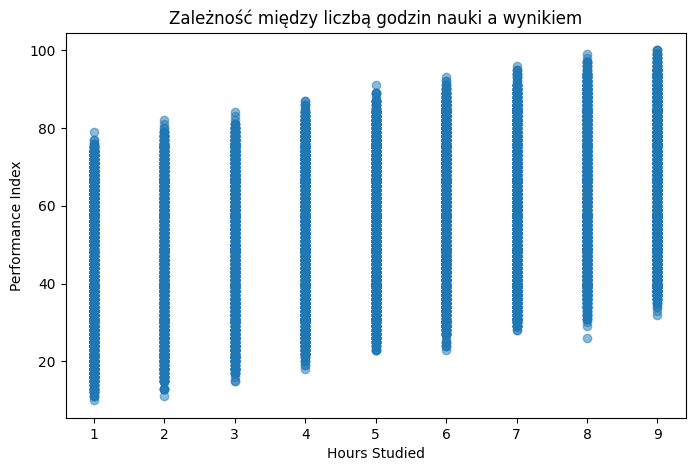

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Hours Studied"], df["Performance Index"], alpha=0.5)

plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.title("Zależność między liczbą godzin nauki a wynikiem")

plt.show()

### Interpretacja

Wykres pokazuje dodatnią zależność między liczbą godzin nauki a wartością Performance Index. Wraz ze wzrostem liczby godzin nauki wyniki zazwyczaj rosną. Jednocześnie dla tej samej liczby godzin występuje zróżnicowanie wyników, co sugeruje, że na osiągnięcia edukacyjne wpływają również inne czynniki.

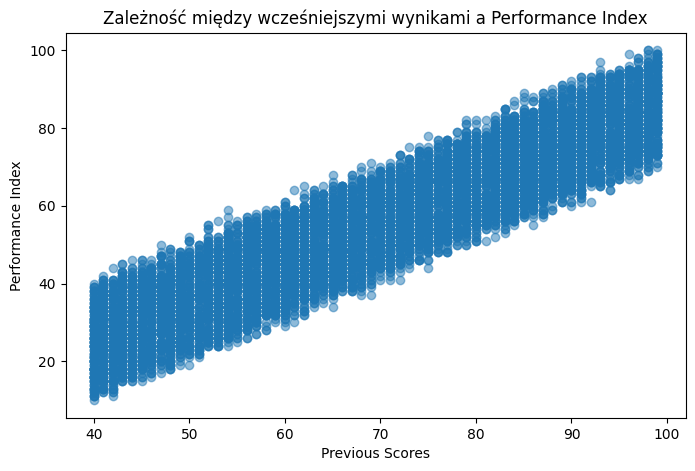

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(df["Previous Scores"], df["Performance Index"], alpha=0.5)

plt.xlabel("Previous Scores")
plt.ylabel("Performance Index")
plt.title("Zależność między wcześniejszymi wynikami a Performance Index")

plt.show()

### Interpretacja

Wykres pokazuje wyraźną dodatnią zależność między wcześniejszymi wynikami a wartością Performance Index. Oznacza to, że osoby, które wcześniej osiągały lepsze rezultaty, zazwyczaj uzyskują również wyższy wynik końcowy.

Punkty układają się w rosnący wzorzec, co sugeruje, że zmienna Previous Scores może być jednym z najważniejszych predyktorów w modelu. Jednocześnie wyniki nie układają się idealnie w jedną linię, dlatego wcześniejsze osiągnięcia nie są jedynym czynnikiem wpływającym na Performance Index.


Macierz korelacji (tabela):


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.010676,0.004899,0.002131,0.015740,0.375332
Previous Scores,-0.010676,1.000000,0.009534,0.007975,0.008719,0.915135
Extracurricular Activities,0.004899,0.009534,1.000000,-0.024008,0.013839,0.026075
Sleep Hours,0.002131,0.007975,-0.024008,1.000000,0.004907,0.050352
Sample Question Papers Practiced,0.015740,0.008719,0.013839,0.004907,1.000000,0.043436
Performance Index,0.375332,0.915135,0.026075,0.050352,0.043436,1.000000


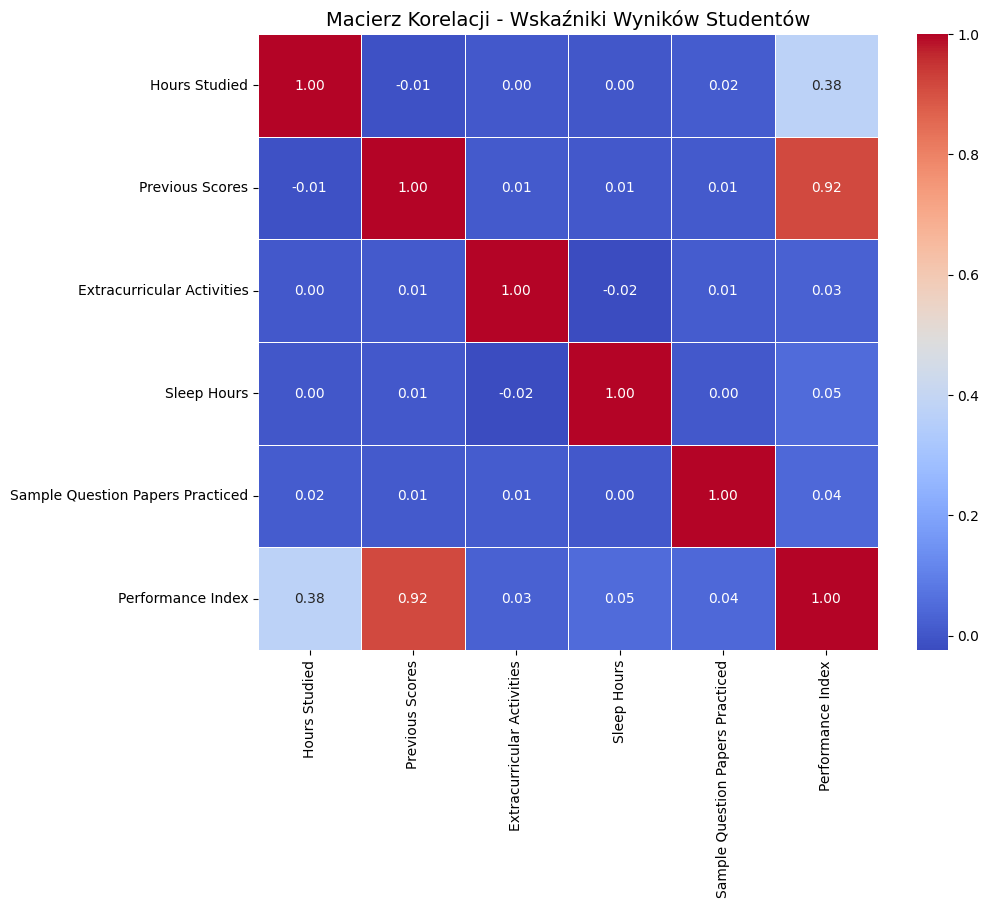

In [42]:
# 3. Obliczenie macierzy korelacji
correlation_matrix = df.corr()

# 4. Wyświetlenie macierzy w formie tekstowej
print("Macierz korelacji (tabela):")
display(correlation_matrix)

# 5. Wizualizacja za pomocą Heatmapy (Seaborn)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
)
plt.title("Macierz Korelacji - Wskaźniki Wyników Studentów", fontsize=14)
plt.show()

### Interpretacja macierzy korelacji

Macierz korelacji pokazuje siłę zależności liniowych między zmiennymi. Najsilniejszą dodatnią korelację z Performance Index ma zmienna Previous Scores, dla której współczynnik korelacji wynosi około 0,92. Oznacza to, że osoby osiągające wysokie wcześniejsze wyniki zazwyczaj uzyskują również wysoki Performance Index.

Drugą najsilniejszą zależność obserwujemy dla zmiennej Hours Studied. Współczynnik około 0,37 wskazuje na umiarkowaną dodatnią korelację, czyli wraz ze wzrostem liczby godzin nauki wynik zazwyczaj rośnie.

Pozostałe zmienne mają słabe korelacje liniowe z Performance Index. Nie oznacza to jednak, że są całkowicie nieistotne, ponieważ modele nieliniowe mogą wykrywać bardziej złożone zależności między cechami.


In [43]:
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

print(X.head())
print()
print(y.head())

   Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0              7               99                           1            9   
1              4               82                           0            4   
2              8               51                           1            7   
3              5               52                           1            5   
4              7               75                           0            8   

   Sample Question Papers Practiced  
0                                 1  
1                                 2  
2                                 2  
3                                 2  
4                                 5  

0    91.0
1    65.0
2    45.0
3    36.0
4    66.0
Name: Performance Index, dtype: float64


In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7898, 5)
X_test: (1975, 5)
y_train: (7898,)
y_test: (1975,)


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import pandas as pd

models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Decision Tree Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", DecisionTreeRegressor(random_state=42))
    ]),

    "Random Forest Regressor": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(random_state=42))
    ])
}

In [47]:
cv_results = []

for model_name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    )

    rmse_scores = -scores

    cv_results.append({
        "Model": model_name,
        "Mean RMSE": rmse_scores.mean(),
        "STD RMSE": rmse_scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values(by="Mean RMSE")

cv_results_df

,Model,Mean RMSE,STD RMSE
0,Linear Regression,2.037286,0.022611
2,Random Forest Regressor,2.352005,0.060505
1,Decision Tree Regressor,3.096908,0.100253


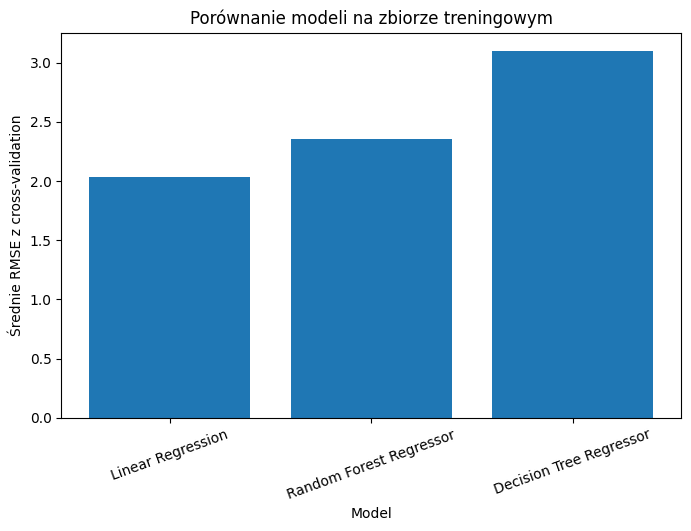

In [48]:
plt.figure(figsize=(8, 5))

plt.bar(cv_results_df["Model"], cv_results_df["Mean RMSE"])

plt.xlabel("Model")
plt.ylabel("Średnie RMSE z cross-validation")
plt.title("Porównanie modeli na zbiorze treningowym")

plt.xticks(rotation=20)
plt.show()

### Porównanie modeli

Wstępna ocena modeli została przeprowadzona za pomocą 5-krotnej walidacji krzyżowej na zbiorze treningowym. Zbiór testowy nie był wykorzystywany na tym etapie, ponieważ zgodnie z zasadami poprawnej ewaluacji powinien zostać użyty dopiero na końcu, do oceny najlepszego modelu.

Porównano trzy modele regresyjne: Linear Regression, Decision Tree Regressor oraz Random Forest Regressor. Najniższa średnia wartość RMSE oznacza model, który uzyskiwał najmniejszy przeciętny błąd predykcji w kolejnych podziałach walidacji krzyżowej.

In [49]:
rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [10, 15, None],
    "model__min_samples_leaf": [1, 2],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=1
)

grid_search.fit(X_train, y_train)

print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepsze średnie RMSE z walidacji:", -grid_search.best_score_)

Najlepsze parametry: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Najlepsze średnie RMSE z walidacji: 2.261447112796862


In [50]:
tuned_rf_result = pd.DataFrame({
    "Model": ["Random Forest po GridSearchCV"],
    "Mean RMSE": [-grid_search.best_score_],
    "STD RMSE": [np.nan]
})

all_results_df = pd.concat(
    [cv_results_df, tuned_rf_result],
    ignore_index=True
)

all_results_df = all_results_df.sort_values(by="Mean RMSE")

all_results_df

,Model,Mean RMSE,STD RMSE
0,Linear Regression,2.037286,0.022611
3,Random Forest po GridSearchCV,2.261447,NaN
1,Random Forest Regressor,2.352005,0.060505
2,Decision Tree Regressor,3.096908,0.100253


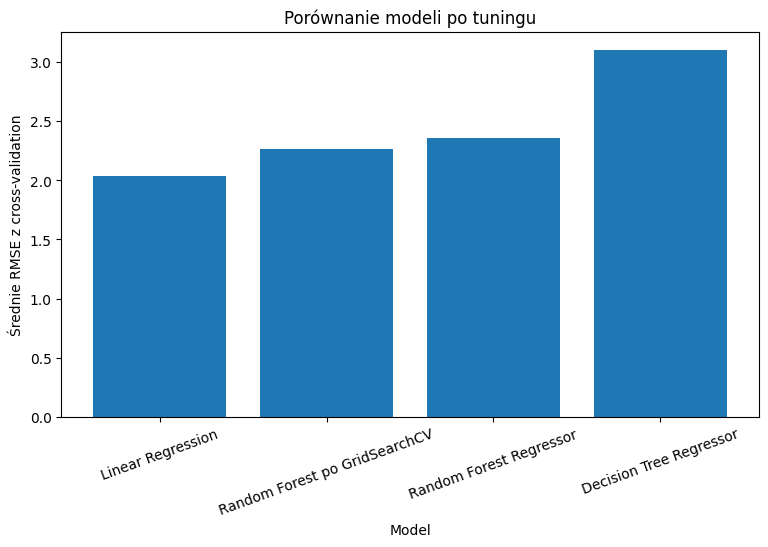

In [51]:
plt.figure(figsize=(9, 5))

plt.bar(all_results_df["Model"], all_results_df["Mean RMSE"])

plt.xlabel("Model")
plt.ylabel("Średnie RMSE z cross-validation")
plt.title("Porównanie modeli po tuningu")

plt.xticks(rotation=20)
plt.show()

In [52]:
best_model_name = all_results_df.iloc[0]["Model"]

if best_model_name == "Random Forest po GridSearchCV":
    best_model = grid_search.best_estimator_
else:
    best_model = models[best_model_name]

print("Najlepszy model:", best_model_name)

Najlepszy model: Linear Regression


In [53]:
best_model.fit(X_train, y_train)

final_predictions = best_model.predict(X_test)

final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_r2 = r2_score(y_test, final_predictions)

print(f"Końcowe RMSE na zbiorze testowym: {final_rmse:.2f}")
print(f"Końcowe R² na zbiorze testowym: {final_r2:.3f}")

Końcowe RMSE na zbiorze testowym: 2.08
Końcowe R² na zbiorze testowym: 0.988


### Końcowa ocena najlepszego modelu

Na podstawie wyników walidacji krzyżowej najlepszym modelem okazała się regresja liniowa. Model ten uzyskał najniższe średnie RMSE na zbiorze treningowym, dlatego został wybrany do końcowej oceny.

Zbiór testowy został wykorzystany dopiero na końcu, wyłącznie do oceny najlepszego modelu. Końcowe RMSE wyniosło około 2.08, co oznacza, że przeciętny błąd predykcji modelu wynosi około 2 punkty w skali `Performance Index`.

Wartość R² wyniosła około 0.988, co oznacza, że model wyjaśnia bardzo dużą część zróżnicowania wyników. Tak wysoki wynik może wynikać z silnych liniowych zależności między zmiennymi, szczególnie między `Previous Scores`, `Hours Studied` i `Performance Index`.